Load libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium
import numpy as np

# Week1

Load data

In [ ]:
f_path = '/content/drive/MyDrive/earthquake_1995-2023.csv'

In [ ]:
df = pd.read_csv(f_path)

In [ ]:
print(df.head())

                                      title  magnitude         date_time  cdi  \
0          M 6.5 - 42 km W of Sola, Vanuatu        6.5  16-08-2023 12:47    7   
1  M 6.5 - 43 km S of Intipucá, El Salvador        6.5  19-07-2023 00:22    8   
2  M 6.6 - 25 km ESE of Loncopué, Argentina        6.6  17-07-2023 03:05    7   
3     M 7.2 - 98 km S of Sand Point, Alaska        7.2  16-07-2023 06:48    6   
4                  M 7.3 - Alaska Peninsula        7.3  16-07-2023 06:48    0   

   mmi   alert  tsunami  sig net  nst      dmin    gap magType    depth  \
0    4   green        0  657  us  114  7.177000   25.0     mww  192.955   
1    6  yellow        0  775  us   92  0.679000   40.0     mww   69.727   
2    5   green        0  899  us   70  1.634000   28.0     mww  171.371   
3    6   green        1  860  us  173  0.907000   36.0     mww   32.571   
4    5     NaN        1  820  at   79  0.879451  172.8      Mi   21.000   

   latitude  longitude               location      continent  

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      1000 non-null   object 
 1   magnitude  1000 non-null   float64
 2   date_time  1000 non-null   object 
 3   cdi        1000 non-null   int64  
 4   mmi        1000 non-null   int64  
 5   alert      449 non-null    object 
 6   tsunami    1000 non-null   int64  
 7   sig        1000 non-null   int64  
 8   net        1000 non-null   object 
 9   nst        1000 non-null   int64  
 10  dmin       1000 non-null   float64
 11  gap        1000 non-null   float64
 12  magType    1000 non-null   object 
 13  depth      1000 non-null   float64
 14  latitude   1000 non-null   float64
 15  longitude  1000 non-null   float64
 16  location   994 non-null    object 
 17  continent  284 non-null    object 
 18  country    651 non-null    object 
dtypes: float64(6), int64(5), object(8)
memory usage: 

In [ ]:
print(df.describe())

         magnitude          cdi         mmi      tsunami          sig  \
count  1000.000000  1000.000000  1000.00000  1000.000000  1000.000000   
mean      6.940150     3.605000     6.02700     0.325000   847.915000   
std       0.438148     3.328972     1.43399     0.468609   301.802632   
min       6.500000     0.000000     1.00000     0.000000   650.000000   
25%       6.600000     0.000000     5.00000     0.000000   691.000000   
50%       6.800000     4.000000     6.00000     0.000000   744.000000   
75%       7.100000     7.000000     7.00000     1.000000   874.250000   
max       9.100000     9.000000    10.00000     1.000000  2910.000000   

               nst         dmin          gap        depth     latitude  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean    193.918000     1.125174    20.926290    74.612541     4.315554   
std     239.045858     2.073164    24.415895   130.812590    26.633320   
min       0.000000     0.000000     0.000000  

In [ ]:
# plt.subplot(4,2,1)
# plt.plot(x,y)
# .
# .
# .
# plt.subplot(4,2,8)
# plt.plot(x,y)

In [ ]:
# fig, ax = plt.subplots(4,2)

# ax[0,0].plot(x,y)
# .
# .
# .
# ax[3,1].plot(x,y)

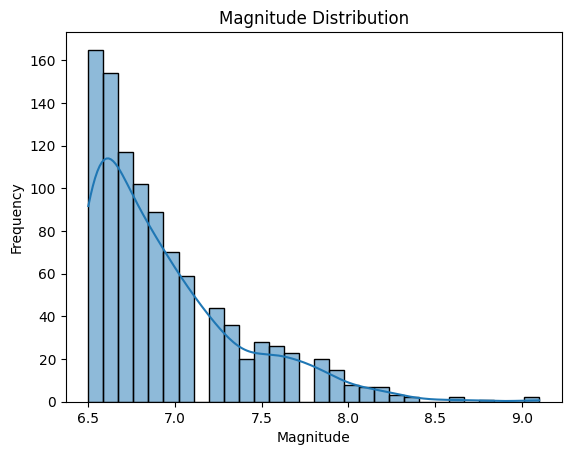

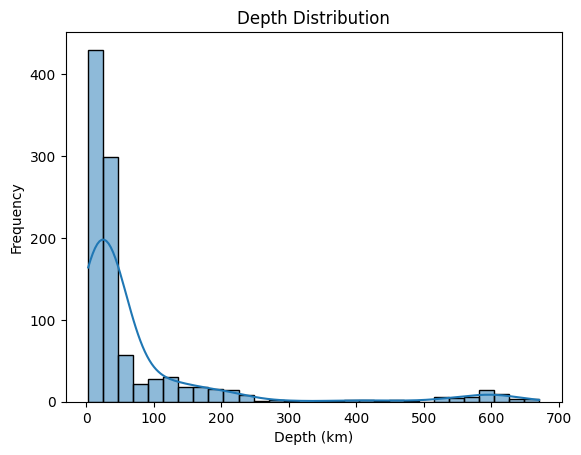

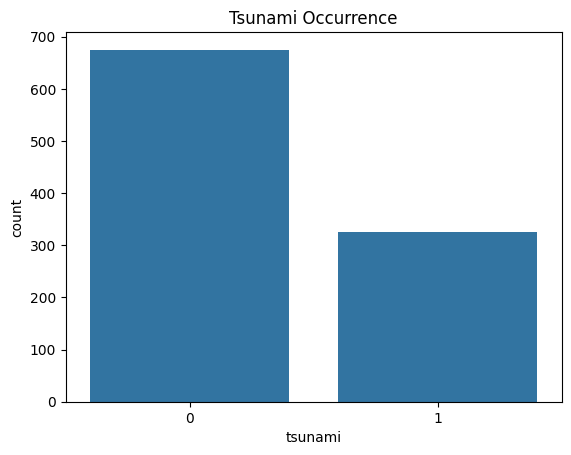

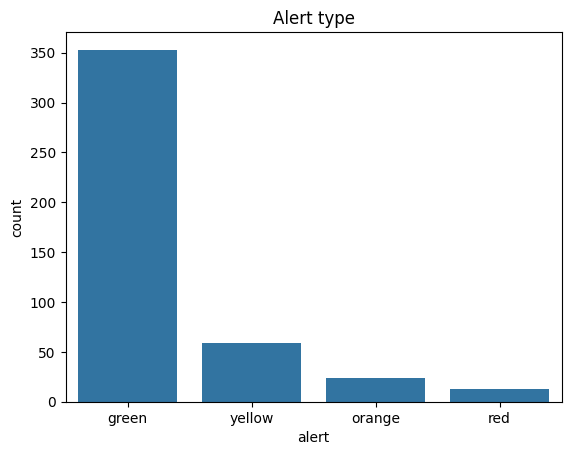

In [ ]:
plt.figure()
sns.histplot(df["magnitude"], bins=30, kde=True)
plt.title("Magnitude Distribution")
plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.show()

plt.figure()
sns.histplot(df["depth"], bins=30, kde=True)
plt.title("Depth Distribution")
plt.xlabel("Depth (km)")
plt.ylabel("Frequency")
plt.show()

plt.figure()
sns.countplot(x="tsunami", data=df)
plt.title("Tsunami Occurrence")
plt.show()

plt.figure()
sns.countplot(x = 'alert', data = df)
plt.title('Alert type')
plt.show()

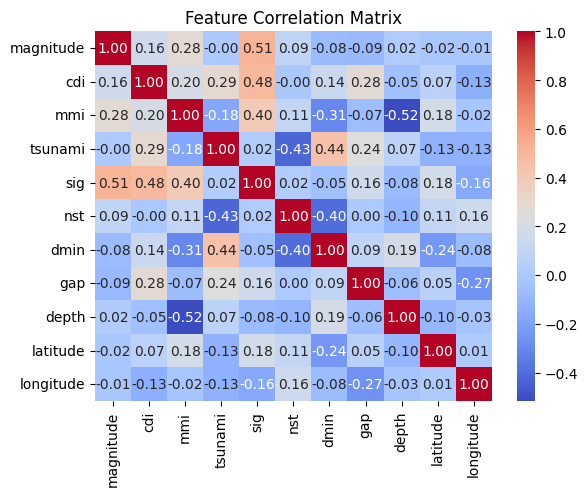

<Figure size 1000x600 with 0 Axes>

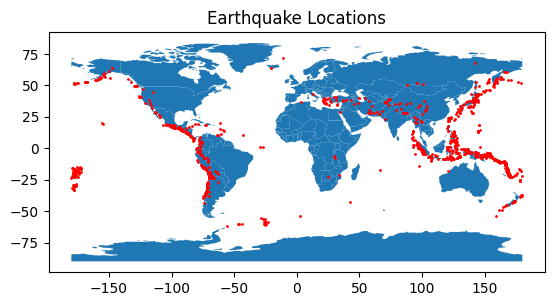

Interactive map saved.


In [ ]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt = '.2f')
plt.title("Feature Correlation Matrix")
plt.show()



gdf = gpd.GeoDataFrame(df,geometry=gpd.points_from_xy(df.longitude, df.latitude),crs="EPSG:4326")

world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")


plt.figure(figsize=(10, 6))
world.plot()
gdf.plot(ax=plt.gca(), markersize=1, color="red")
plt.title("Earthquake Locations")
plt.show()

map_center = [df["latitude"].mean(), df["longitude"].mean()]
m = folium.Map(location=map_center, zoom_start=2)

for _, row in df.iterrows():
    folium.CircleMarker(location=[row["latitude"], row["longitude"]],radius=row["magnitude"],
                        popup=f"Magnitude: {row['magnitude']}, location: {row['continent']}",fill=True).add_to(m)

m.save("earthquake_map.html")

print("Interactive map saved.")

# Week2

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder,
    FunctionTransformer
)
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [ ]:
f_path = '/content/drive/MyDrive/earthquake_1995-2023.csv'

In [ ]:
df = pd.read_csv(f_path)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      1000 non-null   object 
 1   magnitude  1000 non-null   float64
 2   date_time  1000 non-null   object 
 3   cdi        1000 non-null   int64  
 4   mmi        1000 non-null   int64  
 5   alert      449 non-null    object 
 6   tsunami    1000 non-null   int64  
 7   sig        1000 non-null   int64  
 8   net        1000 non-null   object 
 9   nst        1000 non-null   int64  
 10  dmin       1000 non-null   float64
 11  gap        1000 non-null   float64
 12  magType    1000 non-null   object 
 13  depth      1000 non-null   float64
 14  latitude   1000 non-null   float64
 15  longitude  1000 non-null   float64
 16  location   994 non-null    object 
 17  continent  284 non-null    object 
 18  country    651 non-null    object 
dtypes: float64(6), int64(5), object(8)
memory usage: 

In [ ]:
x = df.drop('alert', axis = 1)
k = df.drop(['alert', 'tsunami'], axis = 1)
y = df['alert']
print(x.shape)
print(k.shape)
print(df.shape)

(1000, 18)
(1000, 17)
(1000, 19)


In [ ]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size = 0.2, random_state = 40)
# print(xtrain.shape, xtest.shape, ytrain.shape, ytest.shape)

In [ ]:
numerical_data = xtrain.select_dtypes(include = ['int64', 'float64']).columns
categorical_data = xtrain.select_dtypes(include = ['object', 'category']).columns

In [ ]:
print(categorical_data.shape)
print(numerical_data.shape)
print(df.columns.shape)

(7,)
(11,)
(19,)


In [ ]:
x = xtrain.columns
print(x)

Index(['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'tsunami', 'sig',
       'net', 'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude',
       'longitude', 'location', 'continent', 'country'],
      dtype='object')


Feature Engineering for skewed data.

In [ ]:
numerical_cdata = xtrain.select_dtypes(['int64', 'float64'])
for column in numerical_cdata.columns:
  if abs(numerical_cdata[column].skew()) > 1:
    numerical_cdata[column] = np.log1p(numerical_cdata[column])
    print(column)

magnitude
sig
dmin
gap
depth


In [ ]:
print(xtrain.select_dtypes(['int64', 'float64']))

     magnitude  cdi  mmi  tsunami   sig  nst   dmin    gap    depth  latitude  \
970        7.9    0    8        0   960    0  0.000    0.0   24.000    0.7290   
137        6.8    4    6        0   738    0  1.921   16.0   96.000   -6.7762   
82         6.5    7    5        1   684    0  0.993  114.0   21.000   12.1598   
188        6.5    3    4        1   669    0  1.611   63.0   10.000   49.2586   
358        7.1    4    6        1   779    0  1.397   18.0   45.000    1.8929   
..         ...  ...  ...      ...   ...  ...    ...    ...      ...       ...   
440        6.9    5    6        1   736  531  0.000   20.7   41.000   50.9540   
165        7.6    7    7        1   929    0  0.453   16.0   10.000   -4.0510   
7          7.2    8    6        1   804   85  2.590   24.0  167.404  -22.9824   
219        7.5    8    5        1  1623    0  4.581   12.0   19.000   17.4825   
326        7.0    8    6        1   759    0  5.205   22.0   11.000  -10.4012   

     longitude  
970   119.

In [ ]:
print(numerical_cdata)

     magnitude  cdi  mmi  tsunami       sig  nst      dmin       gap  \
970   2.186051    0    8        0  6.867974    0  0.000000  0.000000   
137   2.054124    4    6        0  6.605298    0  1.071926  2.833213   
82    2.014903    7    5        1  6.529419    0  0.689641  4.744932   
188   2.014903    3    4        1  6.507278    0  0.959733  4.158883   
358   2.091864    4    6        1  6.659294    0  0.874218  2.944439   
..         ...  ...  ...      ...       ...  ...       ...       ...   
440   2.066863    5    6        1  6.602588  531  0.000000  3.077312   
165   2.151762    7    7        1  6.835185    0  0.373630  2.833213   
7     2.104134    8    6        1  6.690842   85  1.278152  3.218876   
219   2.140066    8    5        1  7.392648    0  1.719368  2.564949   
326   2.079442    8    6        1  6.633318    0  1.825355  3.135494   

        depth  latitude  longitude  
970  3.218876    0.7290   119.9310  
137  4.574711   -6.7762   129.7850  
82   3.091042   12.1598 

In [ ]:
def log_transform(x):
  x = x.copy()
  for column in x.columns:
    if abs(x[column].skew()) > 1:
      x[column] = np.log1p(x[column])
      # print(column)
  return x
log_transformer = FunctionTransformer(log_transform)

In [ ]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log_transform", log_transformer),
    ("scaler", StandardScaler())
])

In [ ]:
numeric_pipeline.fit(numerical_cdata)

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [ ]:
from scipy.stats import skew
def log_transform1(x):
  x = x.copy()
  for column in range(x.shape[1]):
    if abs(skew(x[:,column])) > 1:
      x[:,column] = np.log1p(x[:,column])
  return x
log_transformer = FunctionTransformer(log_transform1)

In [ ]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log_transform", log_transformer),
    ("scaler", StandardScaler())
])

In [ ]:
numerical_cdata1 = xtrain.select_dtypes(['int64', 'float64'])
print(numerical_cdata1)
print(numerical_cdata1.shape)

     magnitude  cdi  mmi  tsunami   sig  nst   dmin    gap    depth  latitude  \
970        7.9    0    8        0   960    0  0.000    0.0   24.000    0.7290   
137        6.8    4    6        0   738    0  1.921   16.0   96.000   -6.7762   
82         6.5    7    5        1   684    0  0.993  114.0   21.000   12.1598   
188        6.5    3    4        1   669    0  1.611   63.0   10.000   49.2586   
358        7.1    4    6        1   779    0  1.397   18.0   45.000    1.8929   
..         ...  ...  ...      ...   ...  ...    ...    ...      ...       ...   
440        6.9    5    6        1   736  531  0.000   20.7   41.000   50.9540   
165        7.6    7    7        1   929    0  0.453   16.0   10.000   -4.0510   
7          7.2    8    6        1   804   85  2.590   24.0  167.404  -22.9824   
219        7.5    8    5        1  1623    0  4.581   12.0   19.000   17.4825   
326        7.0    8    6        1   759    0  5.205   22.0   11.000  -10.4012   

     longitude  
970   119.

In [ ]:
numeric_pipeline.fit(numerical_cdata1)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('log_transform',
                 FunctionTransformer(func=<function log_transform1 at 0x7af7a68349a0>)),
                ('scaler', StandardScaler())])

In [ ]:
numerical_data_transformed = numeric_pipeline.fit_transform(numerical_cdata1)

In [ ]:
numerical_data_transformed

array([[ 2.1305971 , -1.08621796,  1.32203788, ..., -0.31197397,
        -0.13503907,  0.57395332],
       [-0.30629843,  0.11071643, -0.02526187, ...,  0.93652944,
        -0.41320863,  0.65950621],
       [-1.03076262,  1.00841722, -0.69891175, ..., -0.42968769,
         0.28862726, -1.23004772],
       ...,
       [ 0.61746751,  1.30765082, -0.02526187, ...,  1.44451376,
        -1.01386837, -2.00582168],
       [ 1.2811845 ,  1.30765082, -0.69891175, ..., -0.51745285,
         0.48590556, -1.19241799],
       [ 0.16135868,  1.30765082, -0.02526187, ..., -0.98784008,
        -0.54756409,  0.9664687 ]])

In [ ]:
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Week3

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder,
    FunctionTransformer
)
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression, LinearRegression, LogisticRegressionCV
from sklearn.metrics import classification_report,mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/earthquake_1995-2023.csv')

In [ ]:
# df.info()

In [ ]:
df['datetime'] = pd.to_datetime(df['date_time'])
df['daytime'] = df['datetime'].dt.hour.apply(lambda x: 'Morning' if 5<=x<=10 else 'Afternoon' if 11<=x<=15 else 'Evening' if 16<=x<=19 else 'Night' )

/tmp/ipykernel_1204/3672297757.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['datetime'] = pd.to_datetime(df['date_time'])


In [ ]:
def getseason(month):
  if month in [12,1,2]:
    return 'Winter'
  elif month in [3,4,5]:
    return 'Spring'
  elif month in [6,7,8]:
    return 'Summer'
  else:
    return 'Autumn'
df['season'] = df['datetime'].dt.month.apply(getseason)

In [ ]:
# df.info()
x = df.drop(['title', 'date_time', 'location', 'continent', 'country', 'datetime', 'magnitude'], axis = 1)
y = df['magnitude']
# x.info()

In [ ]:
x_n = x.select_dtypes(['float64', 'int64'])
x_c = x.select_dtypes('object')
print(x_c.columns)

Index(['alert', 'net', 'magType', 'daytime', 'season'], dtype='object')


In [ ]:
print(x_n.columns)

Index(['cdi', 'mmi', 'tsunami', 'sig', 'nst', 'dmin', 'gap', 'depth',
       'latitude', 'longitude'],
      dtype='object')


In [ ]:
from scipy.stats import skew
def log_transform1(x):
  x = x.copy()
  for column in range(x.shape[1]):
    if abs(skew(x[:,column])) > 1:
      x[:,column] = np.log1p(x[:,column])
  return x
log_transformer = FunctionTransformer(log_transform1)

In [ ]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log_transform", log_transformer),
    ("scaler", StandardScaler())
])

In [ ]:
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown = 'ignore'))
])

In [ ]:
preprocess = ColumnTransformer(
    transformers = [
        ('numerical', numeric_pipeline, x_n.columns),
        ('categorical', categorical_pipeline, x_c.columns)
    ]
)

In [ ]:
f0 = Pipeline(
    steps = [
        ('preprocess', preprocess),
        ('model0', LinearRegression())
    ]
)

In [ ]:
f1 = Pipeline(steps = [
      ('preprocess', preprocess),
      ('model1', LogisticRegression())
    ]
)

In [ ]:
f2 = Pipeline(steps = [
      ('preprocess', preprocess),
      ('model2', LogisticRegression(multi_class = 'ovr'))
    ]
)

In [ ]:
f3 = Pipeline(
    steps = [
        ('preprocess', preprocess),
        ('model3', LogisticRegressionCV(cv = 5))
    ]
)

In [ ]:
f4 = Pipeline(
    steps = [
        ('preprocess', preprocess),
        ('model4', DecisionTreeRegressor(max_depth = 5, random_state = 42))
    ]
)

In [ ]:
f5 = Pipeline(
    steps = [
        ('preprocess', preprocess),
        ('model5', DecisionTreeClassifier(max_depth = 5, criterion = 'gini', random_state = 39))
    ]
)

In [ ]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y, test_size = 0.2, random_state = 40)
f0.fit(xtrain, ytrain)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log_transform',
                                                                   FunctionTransformer(func=<function log_transform1 at 0x7b06bbceda80>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['cdi', 'mmi', 'tsunami', 'sig', 'nst', 'dmin', 'gap', 'depth',
       'latitude', 'longitude'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['alert', 'net', 'magType', 'daytime', 'season'], dtype='object'))])),
                ('model0', LinearRegression())])

In [ ]:
predictions = f0.predict(xtest)
mae = mean_absolute_error(ytest, predictions)
mse = mean_squared_error(ytest, predictions)
r2score = r2_score(ytest, predictions)
print(mse, mae, r2score)

0.08738983126592467 0.20836759878656444 0.4768884935543267


In [ ]:
df['magnitude_class'] = pd.qcut(df['magnitude'], q=3, labels=['Low', 'Medium', 'High'])

In [ ]:
yc = df['magnitude_class']

In [ ]:
xtrain,xtest,ytrain,ytest = train_test_split(x,yc, test_size = 0.2, random_state = 40)
f1.fit(xtrain, ytrain)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log_transform',
                                                                   FunctionTransformer(func=<function log_transform1 at 0x7b06bbceda80>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['cdi', 'mmi', 'tsunami', 'sig', 'nst', 'dmin', 'gap', 'depth',
       'latitude', 'longitude'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['alert', 'net', 'magType', 'daytime', 'season'], dtype='object'))])),
                ('model1', LogisticRegression())])

In [ ]:
predictions = f1.predict(xtest)
print(accuracy_score(ytest, predictions),'\n',classification_report(ytest, predictions),'\n',confusion_matrix(ytest, predictions))

0.615 
               precision    recall  f1-score   support

        High       0.65      0.69      0.67        58
         Low       0.69      0.87      0.77        86
      Medium       0.28      0.14      0.19        56

    accuracy                           0.61       200
   macro avg       0.54      0.57      0.54       200
weighted avg       0.56      0.61      0.58       200
 
 [[40  2 16]
 [ 6 75  5]
 [16 32  8]]


In [ ]:
pred_prob = f1.predict_proba(xtest)
# print(pred_prob)

In [ ]:
f2.fit(xtrain, ytrain)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log_transform',
                                                                   FunctionTransformer(func=<function log_transform1 at 0x7b06bbceda80>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['cdi', 'mmi', 'tsunami', 'sig', 'nst', 'dmin', 'gap', 'depth',
       'latitude', 'longitude'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['alert', 'net', 'magType', 'daytime', 'season'], dtype='object'))])),
                ('model2', LogisticRegression(multi_class='ovr'))])

In [ ]:
predictions = f2.predict(xtest)
print(accuracy_score(ytest, predictions),'\n',classification_report(ytest, predictions),'\n',confusion_matrix(ytest, predictions))

0.66 
               precision    recall  f1-score   support

        High       0.66      0.84      0.74        58
         Low       0.66      0.90      0.76        86
      Medium       0.60      0.11      0.18        56

    accuracy                           0.66       200
   macro avg       0.64      0.62      0.56       200
weighted avg       0.65      0.66      0.59       200
 
 [[49  7  2]
 [ 7 77  2]
 [18 32  6]]


In [ ]:
predictions = f2.predict(xtrain)
print(accuracy_score(ytrain, predictions),'\n',classification_report(ytrain, predictions),'\n',confusion_matrix(ytrain, predictions))

0.695 
               precision    recall  f1-score   support

        High       0.76      0.82      0.79       245
         Low       0.68      0.93      0.79       350
      Medium       0.50      0.14      0.21       205

    accuracy                           0.69       800
   macro avg       0.65      0.63      0.60       800
weighted avg       0.66      0.69      0.64       800
 
 [[201  23  21]
 [ 16 327   7]
 [ 47 130  28]]


In [ ]:
f3.fit(xtrain, ytrain)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log_transform',
                                                                   FunctionTransformer(func=<function log_transform1 at 0x7b06bbceda80>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['cdi', 'mmi', 'tsunami', 'sig', 'nst', 'dmin', 'gap', 'depth',
       'latitude', 'longitude'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['alert', 'net', 'magType', 'daytime', 'season'], dtype='object'))])),
                ('model3', LogisticRegressionCV(cv=5))])

In [ ]:
predictions = f3.predict(xtest)
print(accuracy_score(ytest, predictions),'\n',classification_report(ytest, predictions),'\n',confusion_matrix(ytest, predictions))

0.61 
               precision    recall  f1-score   support

        High       0.64      0.71      0.67        58
         Low       0.69      0.84      0.75        86
      Medium       0.29      0.16      0.21        56

    accuracy                           0.61       200
   macro avg       0.54      0.57      0.54       200
weighted avg       0.56      0.61      0.58       200
 
 [[41  2 15]
 [ 7 72  7]
 [16 31  9]]


In [ ]:
predictions = f3.predict(xtrain)
print(accuracy_score(ytrain, predictions),'\n',classification_report(ytrain, predictions),'\n',confusion_matrix(ytrain, predictions))

0.72375 
               precision    recall  f1-score   support

        High       0.78      0.79      0.78       245
         Low       0.76      0.91      0.83       350
      Medium       0.52      0.33      0.40       205

    accuracy                           0.72       800
   macro avg       0.68      0.68      0.67       800
weighted avg       0.70      0.72      0.70       800
 
 [[193   9  43]
 [ 12 318  20]
 [ 44  93  68]]


In [ ]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y, test_size = 0.2, random_state = 40)
f4.fit(xtrain, ytrain)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log_transform',
                                                                   FunctionTransformer(func=<function log_transform1 at 0x7b06bbceda80>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['cdi', 'mmi', 'tsunami', 'sig', 'nst', 'dmin', 'gap', 'depth',
       'latitude', 'longitude'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['alert', 'net', 'magType', 'daytime', 'season'], dtype='object'))])),
                ('model4',
                 DecisionTreeRegressor(max_depth=5, random_state=42))])

In [ ]:
predictions = f4.predict(xtest)
mae = mean_absolute_error(ytest, predictions)
mse = mean_squared_error(ytest, predictions)
r2score = r2_score(ytest, predictions)
print(mse, mae, r2score)

0.06018392315089869 0.12540965112674438 0.6397418069446124


In [ ]:
predictions = f4.predict(xtrain)
mae = mean_absolute_error(ytrain, predictions)
mse = mean_squared_error(ytrain, predictions)
r2score = r2_score(ytrain, predictions)
print(mse, mae, r2score)

0.04576236810578231 0.10983859889352016 0.7688060261718073


In [ ]:
xtrain,xtest,ytrain,ytest = train_test_split(x,yc, test_size = 0.2, random_state = 40)
f5.fit(xtrain, ytrain)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log_transform',
                                                                   FunctionTransformer(func=<function log_transform1 at 0x7b06bbceda80>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['cdi', 'mmi', 'tsunami', 'sig', 'nst', 'dmin', 'gap', 'depth',
       'latitude', 'longitude'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['alert', 'net', 'magType', 'daytime', 'season'], dtype='object'))])),
                ('model5',
                 DecisionTreeClassifier(max_depth=5, random_state=39))])

In [ ]:
predictions = f5.predict(xtest)
print(accuracy_score(ytest, predictions),'\n',classification_report(ytest, predictions),'\n',confusion_matrix(ytest, predictions))

0.82 
               precision    recall  f1-score   support

        High       0.71      0.93      0.81        58
         Low       0.94      0.86      0.90        86
      Medium       0.80      0.64      0.71        56

    accuracy                           0.82       200
   macro avg       0.82      0.81      0.81       200
weighted avg       0.83      0.82      0.82       200
 
 [[54  0  4]
 [ 7 74  5]
 [15  5 36]]


In [ ]:
predictions = f5.predict(xtrain)
print(accuracy_score(ytrain, predictions),'\n',classification_report(ytrain, predictions),'\n',confusion_matrix(ytrain, predictions))

0.87625 
               precision    recall  f1-score   support

        High       0.78      0.93      0.85       245
         Low       0.98      0.89      0.93       350
      Medium       0.85      0.79      0.82       205

    accuracy                           0.88       800
   macro avg       0.87      0.87      0.87       800
weighted avg       0.89      0.88      0.88       800
 
 [[229   2  14]
 [ 25 310  15]
 [ 39   4 162]]


# Week4

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder,
    FunctionTransformer
)
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression, LinearRegression, LogisticRegressionCV
from sklearn.metrics import classification_report,mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV

In [5]:
df = pd.read_csv('earthquake_1995-2023.csv')

In [6]:
df['datetime'] = pd.to_datetime(df['date_time'])
df['daytime'] = df['datetime'].dt.hour.apply(lambda x: 'Morning' if 5<=x<=10 else 'Afternoon' if 11<=x<=15 else 'Evening' if 16<=x<=19 else 'Night' )

C:\Users\karti\AppData\Local\Temp\ipykernel_27864\3672297757.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['datetime'] = pd.to_datetime(df['date_time'])


In [7]:
def getseason(month):
  if month in [12,1,2]:
    return 'Winter'
  elif month in [3,4,5]:
    return 'Spring'
  elif month in [6,7,8]:
    return 'Summer'
  else:
    return 'Autumn'
df['season'] = df['datetime'].dt.month.apply(getseason)

In [8]:
# df.info()
x = df.drop(['title', 'date_time', 'location', 'continent', 'country', 'datetime', 'magnitude'], axis = 1)
y = df['magnitude']
# x.info()

In [9]:
x_n = x.select_dtypes(['float64', 'int64'])
x_c = x.select_dtypes('object')
print(x_c.columns)
print(x_n.columns)

Index(['alert', 'net', 'magType', 'daytime', 'season'], dtype='object')
Index(['cdi', 'mmi', 'tsunami', 'sig', 'nst', 'dmin', 'gap', 'depth',
       'latitude', 'longitude'],
      dtype='object')


In [5]:
from scipy.stats import skew
def log_transform1(x):
  x = x.copy()
  for column in range(x.shape[1]):
    if abs(skew(x[:,column])) > 1:
      x[:,column] = np.log1p(x[:,column])
  return x
log_transformer = FunctionTransformer(log_transform1, feature_names_out='one-to-one')

In [11]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log_transform", log_transformer),
    ("scaler", StandardScaler())
])

In [12]:
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown = 'ignore'))
])

In [13]:
preprocess = ColumnTransformer(
    transformers = [
        ('numerical', numeric_pipeline, x_n.columns),
        ('categorical', categorical_pipeline, x_c.columns)
    ]
)

In [14]:
am1 = Pipeline(
    steps = [
        ('preprocess', preprocess),
        ('random forest', RandomForestRegressor(
        n_estimators=100,
        max_depth=3,
        random_state=39,
        n_jobs=-1))
        ]
)

In [15]:
am2 = Pipeline(
    steps = [
        ('preprocess', preprocess),
        ('gradient boosting', GradientBoostingRegressor(
        n_estimators=100,
        max_depth=3,
        random_state=3))
        ]
)

In [16]:
am3 = Pipeline(
    steps = [
        ('preprocess', preprocess),
        ('xgboost', XGBRegressor(
        n_estimators=100,
        max_depth=3,
        random_state=39,
        n_jobs=-1))
        ]
)

In [17]:
am4 = Pipeline(
    steps = [
        ('preprocess', preprocess),
        ('histgradient boosting', HistGradientBoostingRegressor(
        max_depth=3,
        max_iter=100,
        random_state=39))
        ]
)

In [18]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y, test_size = 0.2, random_state = 40)
am1.fit(xtrain, ytrain)
am2.fit(xtrain, ytrain)
am3.fit(xtrain, ytrain)
am4.fit(xtrain, ytrain)

,steps,"[('preprocess', ...), ('histgradient boosting', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
predictions1 = am1.predict(xtest)
mae1 = mean_absolute_error(ytest, predictions1)
mse = mean_squared_error(ytest, predictions1)
r2score1 = r2_score(ytest, predictions1)
print(mse, mae1, r2score1)

0.0672427403355366 0.15104174042512208 0.597488052272124


In [20]:
predictions2 = am2.predict(xtest)
mae2 = mean_absolute_error(ytest, predictions2)
mse = mean_squared_error(ytest, predictions2)
r2score2 = r2_score(ytest, predictions2)
print(mse, mae2, r2score2)

0.03885086006724351 0.11194698454040687 0.767440540368564


In [21]:
predictions3 = am3.predict(xtest)
mae3 = mean_absolute_error(ytest, predictions3)
mse = mean_squared_error(ytest, predictions3)
r2score3 = r2_score(ytest, predictions3)
print(mse, mae3, r2score3)

0.03932478260087442 0.11257794237136841 0.7646036619021002


In [22]:
predictions4 = am4.predict(xtest)
mae4 = mean_absolute_error(ytest, predictions4)
mse = mean_squared_error(ytest, predictions4)
r2score4 = r2_score(ytest, predictions4)
print(mse, mae4, r2score4)

0.04680254176381124 0.12550723198821653 0.7198421398360073


Predictions on train data.

In [23]:
predictions1 = am1.predict(xtrain)
mae1 = mean_absolute_error(ytrain, predictions1)
mse = mean_squared_error(ytrain, predictions1)
r2score1 = r2_score(ytrain, predictions1)
print(mse, mae1, r2score1)

0.058952270671176026 0.14367255610845725 0.7021699206833167


In [24]:
predictions2 = am2.predict(xtrain)
mae2 = mean_absolute_error(ytrain, predictions2)
mse = mean_squared_error(ytrain, predictions2)
r2score2 = r2_score(ytrain, predictions2)
print(mse, mae2, r2score2)

0.015448821396062597 0.07670611280147768 0.9219517136599751


In [25]:
predictions3 = am3.predict(xtrain)
mae3 = mean_absolute_error(ytrain, predictions3)
mse = mean_squared_error(ytrain, predictions3)
r2score3 = r2_score(ytrain, predictions3)
print(mse, mae3, r2score3)

0.004050561218153772 0.04278717794418336 0.9795363443147295


In [26]:
predictions4 = am4.predict(xtrain)
mae4 = mean_absolute_error(ytrain, predictions4)
mse = mean_squared_error(ytrain, predictions4)
r2score4 = r2_score(ytrain, predictions4)
print(mse, mae4, r2score4)

0.02236773918497518 0.09023242124085573 0.886996964497701


Using cross validation

In [27]:
print('---------------------Cross Validation-------------------------')
scores10 = cross_val_score(am1, xtrain, ytrain, cv=5, scoring='r2')
scores11 = cross_val_score(am1, xtrain, ytrain,cv=5,scoring='neg_mean_absolute_error')
print("R2 scores model 1(random forest):", scores10)
print("Mean R2 model 1(random forest):", scores10.mean())
print("MAE model 1(random forest):", scores11*-1)
print("Mean MAE model 1(random forest):", scores11.mean()*-1)
print('---------------------xxxxxxxxxxxxxxxx-------------------------')
scores20 = cross_val_score(am2, xtrain, ytrain, cv=5, scoring='r2')
scores21 = cross_val_score(am2, xtrain, ytrain,cv=5,scoring='neg_mean_absolute_error')
print("R2 scores model 2(gradient boosting):", scores20)
print("Mean R2 model 2(gradient boosting):", scores20.mean())
print("MAE model 2(gradient boosting):", scores21*-1)
print("Mean MAE model 2(gradient boosting):", scores21.mean()*-1)
print('---------------------xxxxxxxxxxxxxxxx-------------------------')
scores30 = cross_val_score(am3, xtrain, ytrain, cv=5, scoring='r2')
scores31 = cross_val_score(am3, xtrain, ytrain,cv=5,scoring='neg_mean_absolute_error')
print("R2 scores model 3(xgboost):", scores30)
print("Mean R2 model 3(xgboost):", scores30.mean())
print("MAE model 3(xgboost):", scores31*-1)
print("Mean MAE model 3(xgboost):", scores31.mean()*-1)
print('---------------------xxxxxxxxxxxxxxxx-------------------------')
scores40 = cross_val_score(am4, xtrain, ytrain, cv=5, scoring='r2')
scores41 = cross_val_score(am4, xtrain, ytrain,cv=5,scoring='neg_mean_absolute_error')
print("R2 scores model 4(hist gradient boosting):", scores40)
print("Mean R2 model 4(hist gradient boosting):", scores40.mean())
print("MAE model 4(hist gradient boosting):", scores41*-1)
print("Mean MAE model 4(hist gradient boosting):", scores41.mean()*-1)

---------------------Cross Validation-------------------------
R2 scores model 1(random forest): [0.67097742 0.56491844 0.66595104 0.80429948 0.61295408]
Mean R2 model 1(random forest): 0.6638200929924782
MAE model 1(random forest): [0.15993611 0.16168044 0.14753513 0.11451916 0.18049866]
Mean MAE model 1(random forest): 0.1528339006556696
---------------------xxxxxxxxxxxxxxxx-------------------------
R2 scores model 2(gradient boosting): [0.76921726 0.72068369 0.79618609 0.8804548  0.71596339]
Mean R2 model 2(gradient boosting): 0.7765010433857419
MAE model 2(gradient boosting): [0.12433509 0.12371049 0.10901435 0.09225708 0.14356464]
Mean MAE model 2(gradient boosting): 0.11857632820525166
---------------------xxxxxxxxxxxxxxxx-------------------------
R2 scores model 3(xgboost): [0.80339694 0.72750684 0.81520985 0.85019753 0.72183737]
Mean R2 model 3(xgboost): 0.7836297065497045
MAE model 3(xgboost): [0.12015751 0.12227549 0.1043738  0.10363817 0.14450599]
Mean MAE model 3(xgboost): 

Hyperparameter Tuning

In [28]:
param1 = {
    'random forest__n_estimators' : [50, 100, 150],
    'random forest__max_depth': [3, 5, 10],
    'random forest__max_features': [1.0, 'sqrt', 'log2']
}
param2 = {
    'gradient boosting__n_estimators': [20, 50, 100],
    'gradient boosting__learning_rate': [0.01, 0.1],
    'gradient boosting__max_depth': [1, 3]
}
param3 = {
    'xgboost__n_estimators': [20, 50, 100],
    'xgboost__learning_rate': [0.01, 0.1],
    'xgboost__max_depth': [1, 2, 3]
}
param4 = {
    'histgradient boosting__max_iter': [20, 50, 100],
    'histgradient boosting__learning_rate': [0.01, 0.1],
    'histgradient boosting__max_depth': [1, 3, 5]
}
scoring_metric = {
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
}

0.058952270671176026 0.14367255610845728 0.7021699206833167

0.015448821396062597 0.07670611280147768 0.9219517136599751

0.0046586592554640005 0.045005687117576604 0.9764641999406032

0.02236773918497518 0.09023242124085573 0.886996964497701

In [29]:
grid_search1 = GridSearchCV(estimator=am1, param_grid=param1, cv=5, scoring=scoring_metric, refit = 'MAE',n_jobs=-1)
grid_search1.fit(xtrain, ytrain)
print(f"Best Params (via MAE): {grid_search1.best_params_}")
print(f"Best MAE Score: {-grid_search1.best_score_}")
best_index1 = grid_search1.best_index_
best_r21 = grid_search1.cv_results_['mean_test_R2'][best_index1]
print(f"Associated R2 Score: {best_r21}")

Best Params (via MAE): {'random forest__max_depth': 10, 'random forest__max_features': 1.0, 'random forest__n_estimators': 150}
Best MAE Score: 0.11270919251669839
Associated R2 Score: 0.7674793914960116


In [30]:
grid_search2 = GridSearchCV(estimator=am2, param_grid=param2, cv=5, scoring=scoring_metric, refit = 'MAE',n_jobs=-1)
grid_search2.fit(xtrain, ytrain)
print(f"Best Params (via MAE): {grid_search2.best_params_}")
print(f"Best MAE Score: {-grid_search2.best_score_}")
best_index2 = grid_search2.best_index_
best_r22 = grid_search2.cv_results_['mean_test_R2'][best_index2]
print(f"Associated R2 Score: {best_r22}")

Best Params (via MAE): {'gradient boosting__learning_rate': 0.1, 'gradient boosting__max_depth': 3, 'gradient boosting__n_estimators': 100}
Best MAE Score: 0.11857632820525166
Associated R2 Score: 0.7765010433857419


In [31]:
grid_search3 = GridSearchCV(estimator=am3, param_grid=param3, cv=5, scoring=scoring_metric, refit = 'MAE',n_jobs=-1)
grid_search3.fit(xtrain, ytrain)
print(f"Best Params (via MAE): {grid_search3.best_params_}")
print(f"Best MAE Score: {-grid_search3.best_score_}")
best_index3 = grid_search3.best_index_
best_r23 = grid_search3.cv_results_['mean_test_R2'][best_index3]
print(f"Associated R2 Score: {best_r23}")

Best Params (via MAE): {'xgboost__learning_rate': 0.1, 'xgboost__max_depth': 3, 'xgboost__n_estimators': 100}
Best MAE Score: 0.12107386448383332
Associated R2 Score: 0.7752806540940786


In [32]:
grid_search4 = GridSearchCV(estimator=am4, param_grid=param4, cv=5, scoring=scoring_metric, refit = 'MAE',n_jobs=-1)
grid_search4.fit(xtrain, ytrain)
print(f"Best Params (via MAE): {grid_search4.best_params_}")
print(f"Best MAE Score: {-grid_search4.best_score_}")
best_index4 = grid_search4.best_index_
best_r24 = grid_search4.cv_results_['mean_test_R2'][best_index4]
print(f"Associated R2 Score: {best_r24}")

Best Params (via MAE): {'histgradient boosting__learning_rate': 0.1, 'histgradient boosting__max_depth': 5, 'histgradient boosting__max_iter': 100}
Best MAE Score: 0.1175713165079568
Associated R2 Score: 0.7549216722505108


Evaluation

In [34]:
grid_pred1 = grid_search1.predict(xtest)
test_r2 = r2_score(ytest, grid_pred1)
print(f"Grid Search Test MAE: {mean_absolute_error(ytest, grid_pred1)}")
print(f'Grid Search Test r2 score: {test_r2}')
grid_pred1 = grid_search1.predict(xtrain)
train_r2 = r2_score(ytrain, grid_pred1)
print(f"Grid Search Train MAE: {mean_absolute_error(ytrain, grid_pred1)}")
print(f'Grid Search Train r2 score: {train_r2}')

Grid Search Test MAE: 0.099536452704126
Grid Search Test r2 score: 0.7783904224191436
Grid Search Train MAE: 0.04864629501769031
Grid Search Train r2 score: 0.9530460999655488


In [35]:
grid_pred1 = grid_search2.predict(xtest)
test_r2 = r2_score(ytest, grid_pred1)
print(f"Grid Search Test MAE: {mean_absolute_error(ytest, grid_pred1)}")
print(f'Grid Search Test r2 score: {test_r2}')
grid_pred1 = grid_search2.predict(xtrain)
train_r2 = r2_score(ytrain, grid_pred1)
print(f"Grid Search Train MAE: {mean_absolute_error(ytrain, grid_pred1)}")
print(f'Grid Search Train r2 score: {train_r2}')

Grid Search Test MAE: 0.11194698454040687
Grid Search Test r2 score: 0.767440540368564
Grid Search Train MAE: 0.07670611280147768
Grid Search Train r2 score: 0.9219517136599751


In [36]:
grid_pred1 = grid_search3.predict(xtest)
test_r2 = r2_score(ytest, grid_pred1)
print(f"Grid Search Test MAE: {mean_absolute_error(ytest, grid_pred1)}")
print(f'Grid Search Test r2 score: {test_r2}')
grid_pred1 = grid_search3.predict(xtrain)
train_r2 = r2_score(ytrain, grid_pred1)
print(f"Grid Search Train MAE: {mean_absolute_error(ytrain, grid_pred1)}")
print(f'Grid Search Train r2 score: {train_r2}')

Grid Search Test MAE: 0.11392574071884157
Grid Search Test r2 score: 0.7585126236879013
Grid Search Train MAE: 0.08230892705917359
Grid Search Train r2 score: 0.903307575378141


In [37]:
import joblib

joblib.dump(grid_search1, 'random_forest_model.pkl')

['random_forest_model.pkl']

# Week5

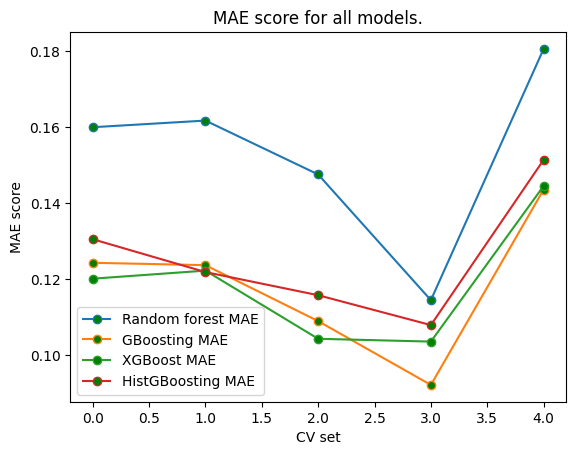

In [31]:
fig, ax = plt.subplots()
ax.plot(scores11*-1,
        label = 'Random forest MAE',
        marker = 'o',
        markerfacecolor = 'green')
ax.plot(scores21*-1,
        label = 'GBoosting MAE',
        marker = 'o',
        markerfacecolor = 'green')
ax.plot(scores31*-1,
        label = 'XGBoost MAE',
        marker = 'o',
        markerfacecolor = 'green')
ax.plot(scores41*-1,
        label = 'HistGBoosting MAE',
        marker = 'o',
        markerfacecolor = 'green')
ax.set_xlabel('CV set')
ax.set_ylabel('MAE score')
ax.set_title('MAE score for all models.')
ax.legend()
plt.show()

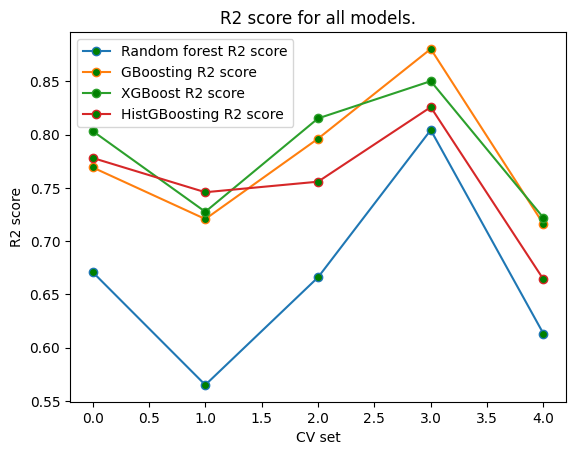

In [32]:
fig, ax = plt.subplots()
ax.plot(scores10,
        label = 'Random forest R2 score',
        marker = 'o',
        markerfacecolor = 'green')
ax.plot(scores20,
        label = 'GBoosting R2 score',
        marker = 'o',
        markerfacecolor = 'green')
ax.plot(scores30,
        label = 'XGBoost R2 score',
        marker = 'o',
        markerfacecolor = 'green')
ax.plot(scores40,
        label = 'HistGBoosting R2 score',
        marker = 'o',
        markerfacecolor = 'green')
ax.set_xlabel('CV set')
ax.set_ylabel('R2 score')
ax.set_title('R2 score for all models.')
ax.legend()
plt.show()

In [33]:
hyper_param_tuned_mae = [-grid_search1.best_score_, -grid_search2.best_score_, -grid_search3.best_score_, -grid_search4.best_score_]
hyper_param_tuned_r2 = [best_r21, best_r22, best_r23, best_r24]

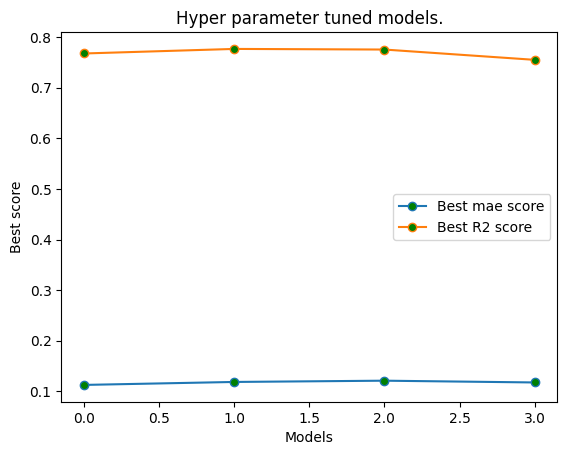

In [34]:
fig, ax = plt.subplots()
ax.plot(hyper_param_tuned_mae,
        label = 'Best mae score',
        marker = 'o',
        markerfacecolor = 'green')
ax.plot(hyper_param_tuned_r2,
        label = 'Best R2 score',
        marker = 'o',
        markerfacecolor = 'green')
ax.set_xlabel('Models')
ax.set_ylabel('Best score')
ax.set_title('Hyper parameter tuned models.')
ax.legend()
plt.show()

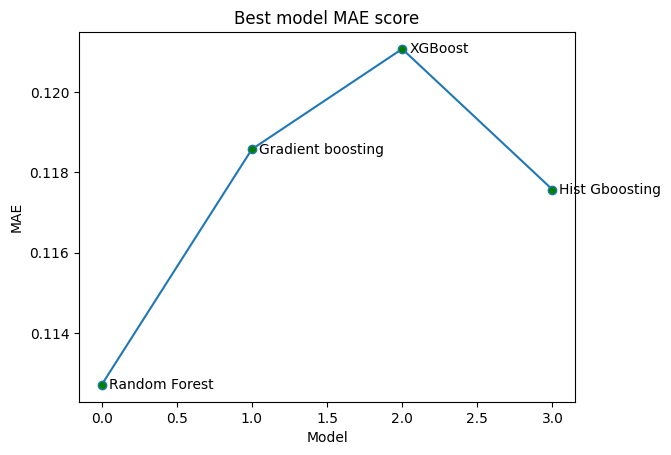

In [35]:
names = ['Random Forest', 'Gradient boosting', 'XGBoost', 'Hist Gboosting']

fig, ax = plt.subplots()
ax.plot(hyper_param_tuned_mae, label='Best mae score', marker='o', mfc='green')

for i, val in enumerate(hyper_param_tuned_mae):
    label_text = names[i]
    ax.annotate(label_text, (i, val), xytext=(5, -3),
                textcoords="offset points")

ax.set(xlabel='Model', ylabel='MAE')
ax.set_title('Best model MAE score')
plt.show()

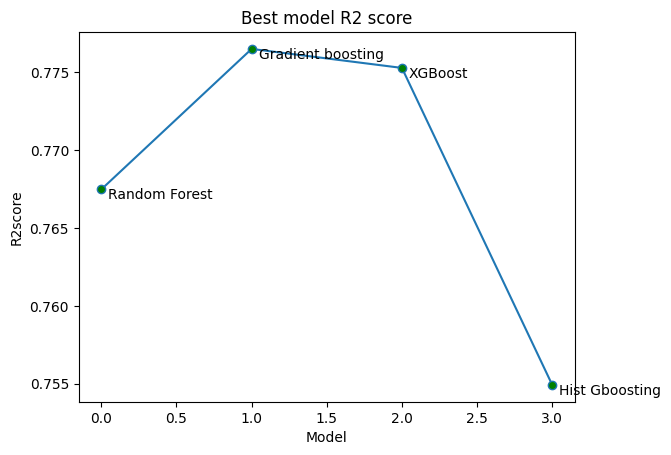

In [36]:
names = ['Random Forest', 'Gradient boosting', 'XGBoost', 'Hist Gboosting']

fig, ax = plt.subplots()
ax.plot(hyper_param_tuned_r2, label='Best R2 score', marker='o', mfc='green')

for i, val in enumerate(hyper_param_tuned_r2):
    label_text = names[i]
    ax.annotate(label_text, (i, val), xytext=(5, -7),
                textcoords="offset points")

ax.set(xlabel='Model', ylabel='R2score')
ax.set_title('Best model R2 score')
plt.show()

In [37]:
import shap

def plot_feature_importance(model, feature_names):
    importances = pd.Series(model.feature_importances_, index=feature_names)
    importances.nlargest(10).plot(kind='barh')
    plt.title("Top 10 Feature Importances")
    plt.show()

def plot_shap_summary(model, X_train):
    explainer = shap.Explainer(model)
    shap_values = explainer(X_train)
    shap.summary_plot(shap_values, X_train)

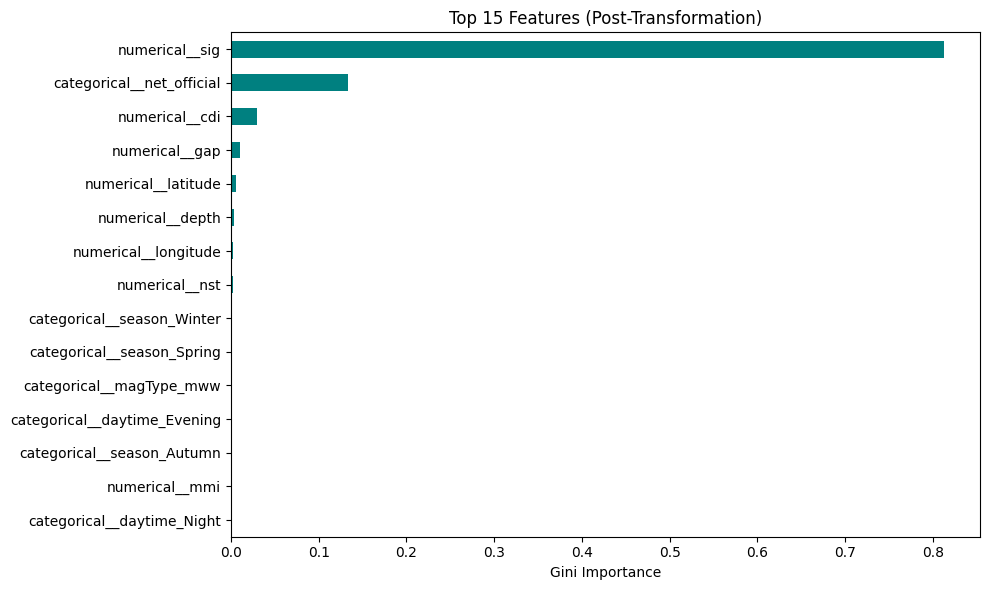

In [38]:
def plot_pipeline_importance(pipeline):
    model = pipeline[-1]
    try:
        feature_names = pipeline[:-1].get_feature_names_out()
    except:
        print("Could not auto-extract feature names; using generic labels.")
        feature_names = [f"Feature {i}" for i in range(len(model.feature_importances_))]

    importances = pd.Series(model.feature_importances_, index=feature_names)
    plt.figure(figsize=(10, 6))
    importances.nlargest(15).sort_values().plot(kind='barh', color='teal')
    plt.title("Top 15 Features (Post-Transformation)")
    plt.xlabel("Gini Importance")
    plt.tight_layout()
    plt.show()

plot_pipeline_importance(am1)

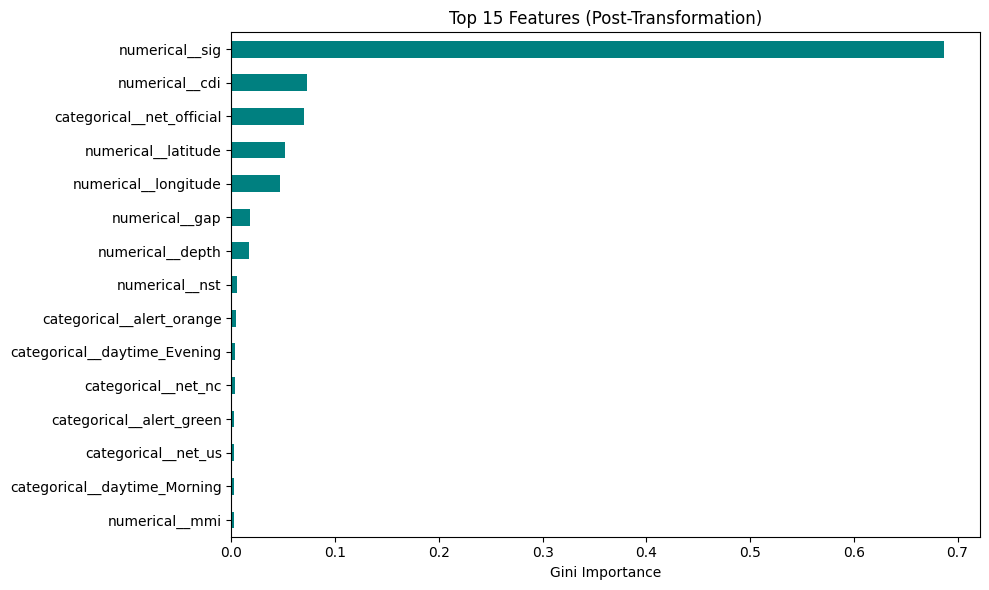

In [39]:
plot_pipeline_importance(am2)

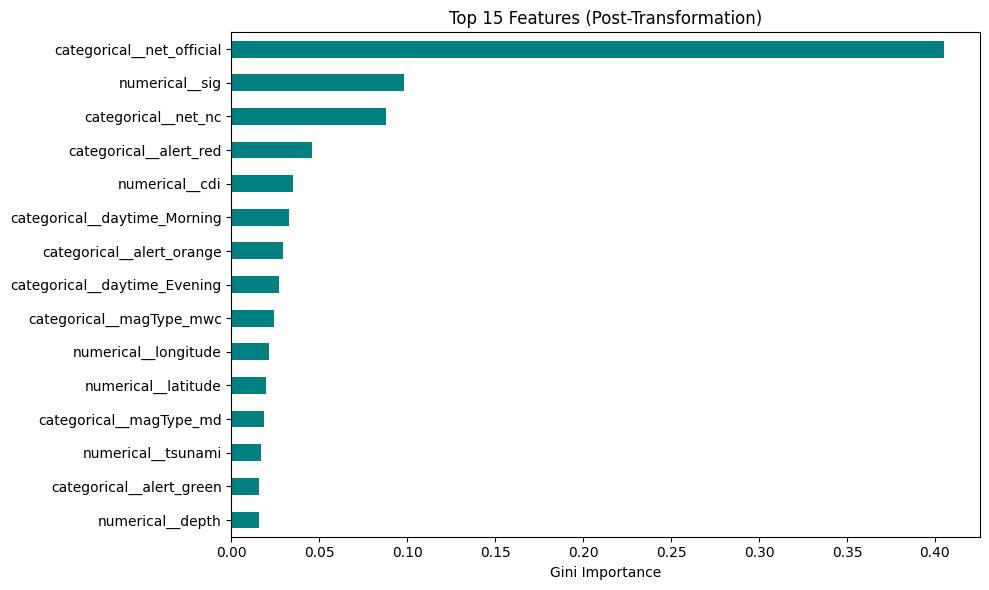

In [40]:
plot_pipeline_importance(am3)

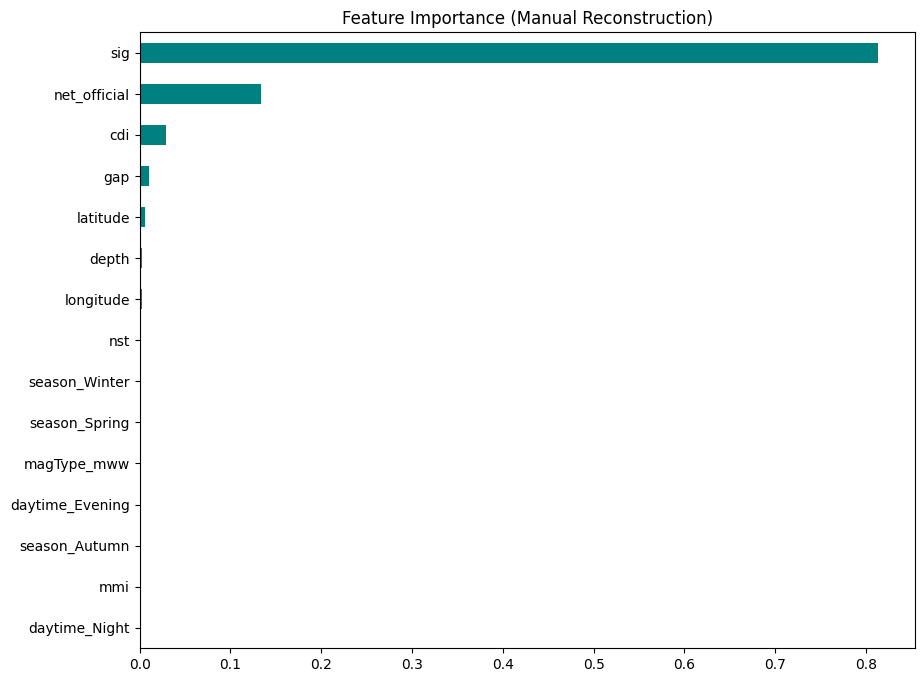

In [41]:
preprocessor = am1.named_steps['preprocess']
model = am1.named_steps['random forest']
numeric_names = list(x_n.columns)
cat_pipeline = preprocessor.named_transformers_['categorical']
ohe_step = cat_pipeline.named_steps['encoder']
categorical_names = list(ohe_step.get_feature_names_out(x_c.columns))
feature_names = numeric_names + categorical_names
if len(feature_names) != len(model.feature_importances_):
    print(f"Error: Names ({len(feature_names)}) don't match Importance values ({len(model.feature_importances_)})")
else:
    importances = pd.Series(model.feature_importances_, index=feature_names)
    plt.figure(figsize=(10, 8))
    importances.nlargest(15).sort_values().plot(kind='barh', color='teal')
    plt.title("Feature Importance (Manual Reconstruction)")
    plt.show()

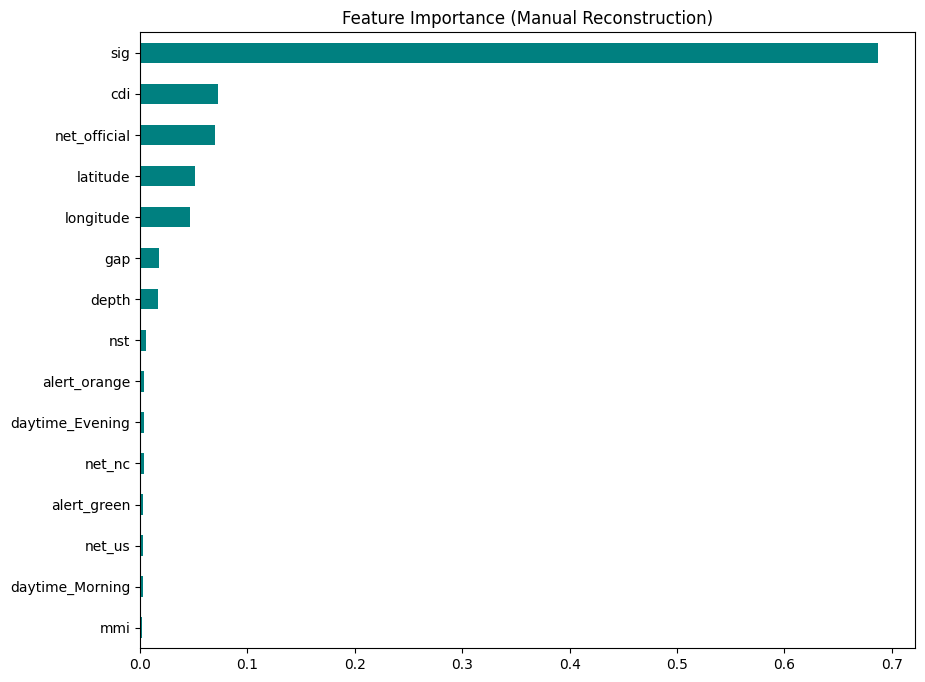

In [42]:
preprocessor = am2.named_steps['preprocess']
model = am2.named_steps['gradient boosting']
numeric_names = list(x_n.columns)
cat_pipeline = preprocessor.named_transformers_['categorical']
ohe_step = cat_pipeline.named_steps['encoder']
categorical_names = list(ohe_step.get_feature_names_out(x_c.columns))
feature_names = numeric_names + categorical_names
if len(feature_names) != len(model.feature_importances_):
    print(f"Error: Names ({len(feature_names)}) don't match Importance values ({len(model.feature_importances_)})")
else:
    importances = pd.Series(model.feature_importances_, index=feature_names)
    plt.figure(figsize=(10, 8))
    importances.nlargest(15).sort_values().plot(kind='barh', color='teal')
    plt.title("Feature Importance (Manual Reconstruction)")
    plt.show()

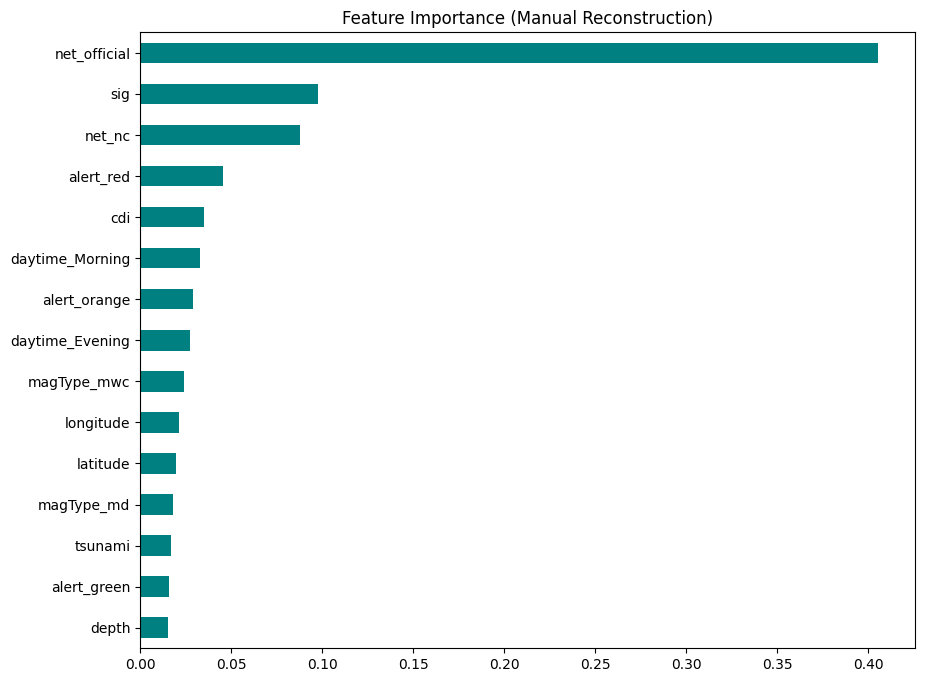

In [43]:
preprocessor = am3.named_steps['preprocess']
model = am3.named_steps['xgboost']
numeric_names = list(x_n.columns)
cat_pipeline = preprocessor.named_transformers_['categorical']
ohe_step = cat_pipeline.named_steps['encoder']
categorical_names = list(ohe_step.get_feature_names_out(x_c.columns))
feature_names = numeric_names + categorical_names
if len(feature_names) != len(model.feature_importances_):
    print(f"Error: Names ({len(feature_names)}) don't match Importance values ({len(model.feature_importances_)})")
else:
    importances = pd.Series(model.feature_importances_, index=feature_names)
    plt.figure(figsize=(10, 8))
    importances.nlargest(15).sort_values().plot(kind='barh', color='teal')
    plt.title("Feature Importance (Manual Reconstruction)")
    plt.show()

In [44]:
model = am1.named_steps['random forest']

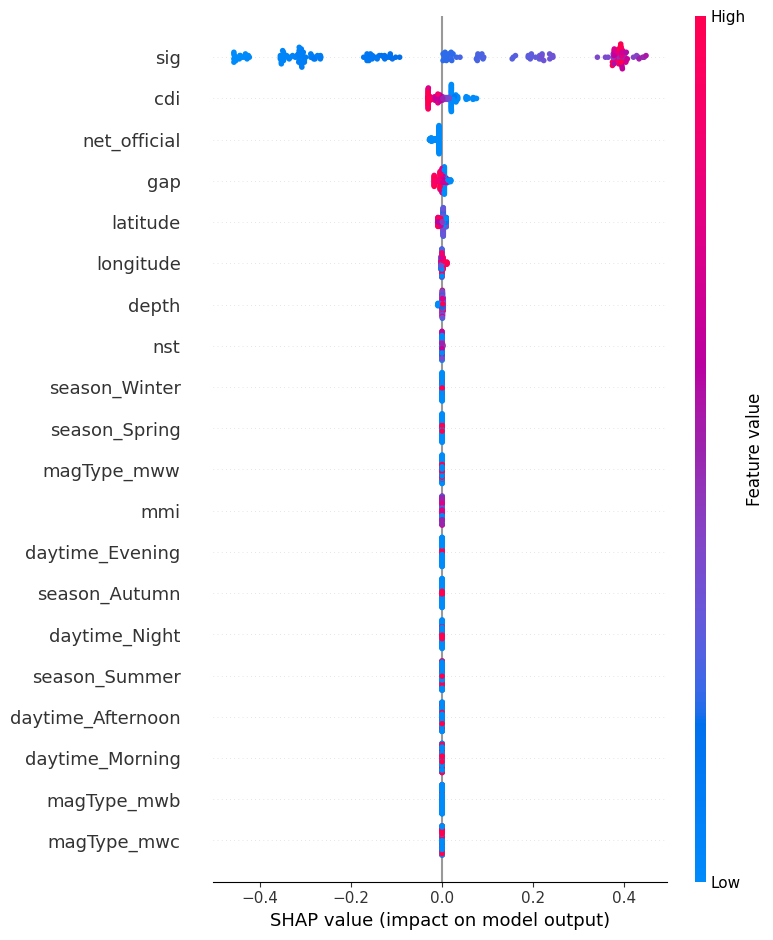

In [45]:
xtest_transformed = preprocessor.transform(xtest)

xtest_df = pd.DataFrame(
    xtest_transformed.toarray() if hasattr(xtest_transformed, "toarray") else xtest_transformed,
    columns=feature_names
)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(xtest_df)
shap.summary_plot(shap_values, xtest_df)

In [46]:
model = am2.named_steps['gradient boosting']

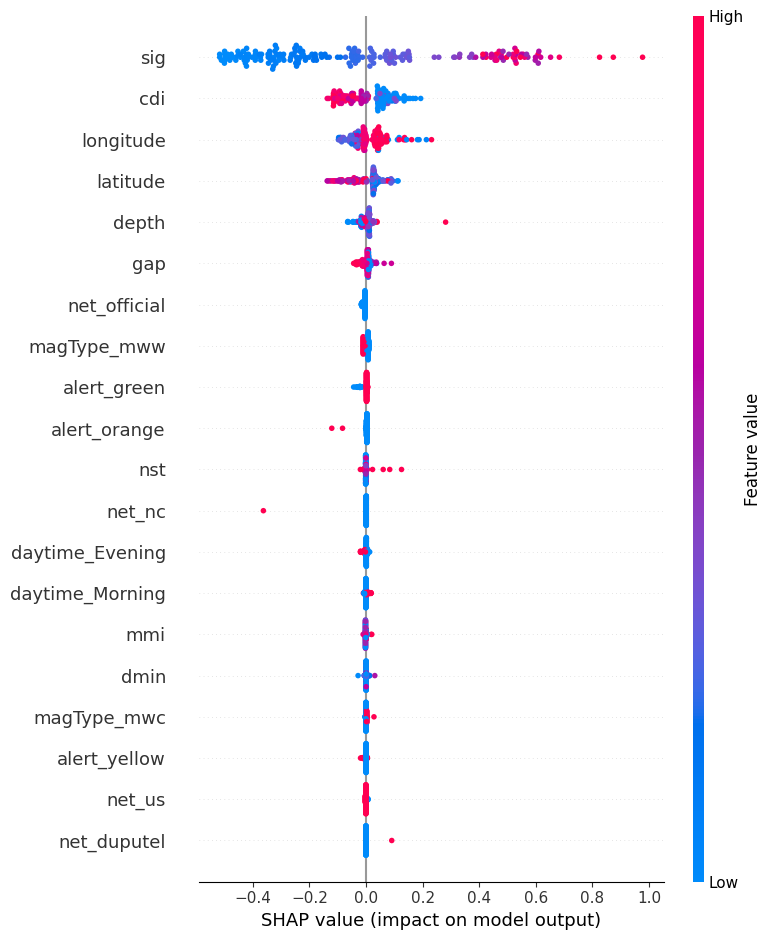

In [47]:
xtest_transformed = preprocessor.transform(xtest)

xtest_df = pd.DataFrame(
    xtest_transformed.toarray() if hasattr(xtest_transformed, "toarray") else xtest_transformed,
    columns=feature_names
)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(xtest_df)
shap.summary_plot(shap_values, xtest_df)

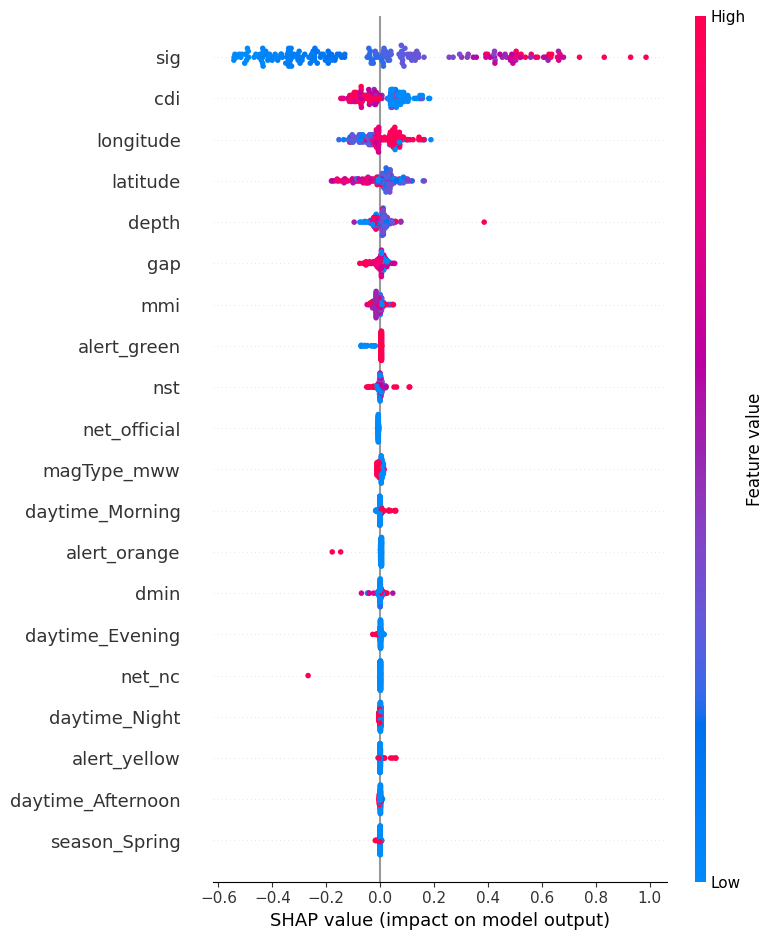

In [49]:
model_step = am3.named_steps['xgboost']
xtest_transformed = preprocessor.transform(xtest)

xtest_df = pd.DataFrame(
    xtest_transformed.toarray() if hasattr(xtest_transformed, "toarray") else xtest_transformed,
    columns=feature_names
)

explainer = shap.TreeExplainer(model_step)
shap_values = explainer.shap_values(xtest_df)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, xtest_df, show=False)
plt.show()

# Week6

In [6]:
import joblib

model = joblib.load('random_forest_model.pkl')
if hasattr(model, 'feature_names_in_'):
    print("Your model expects these features in this order:")
    print(model.feature_names_in_)
else:
    print("No feature names found. Check n_features_in_ for the count:")
    print(model.n_features_in_)

Your model expects these features in this order:
['cdi' 'mmi' 'alert' 'tsunami' 'sig' 'net' 'nst' 'dmin' 'gap' 'magType'
 'depth' 'latitude' 'longitude' 'daytime' 'season']


In [8]:
df = pd.read_csv('earthquake_1995-2023.csv')

In [31]:
print((df['depth'].unique()))

[192.955  69.727 171.371  32.571  21.     10.    229.    167.404  35.981
  18.027 210.097 598.467  15.462  43.063 595.854 594.028 105.631  62.603
 209.976 187.589  65.842  22.065 205.681 598.925  20.522  14.497  17.925
 610.671  28.566 105.249  29.     38.     14.     25.    579.     37.
 624.464 660.    630.379  20.     26.943 137.    116.     12.     30.
  33.729 622.73  236.    220.     27.     24.     41.     28.    535.
 110.      8.     33.     19.     13.    165.49   14.27  126.     51.6
 527.      6.      7.     93.     16.7    33.3    20.74   22.79   47.23
  55.14   46.66   35.     11.     43.    246.    301.     13.23   28.93
  43.98   15.     80.     28.37   16.    624.     26.     22.     73.
 533.76  165.    112.      2.7   107.     96.     12.06   57.8   143.
  14.86   18.    577.     12.26  591.     49.    181.     18.98  212.
  46.     57.92  122.57  146.     15.46  267.    145.     66.     63.
  43.21  570.41   60.21   16.56  133.     46.7   540.     17.    461.
  39. 